In [4]:
import pandas as pd
import geopandas as gpd

df = pd.read_csv('../downloads/forest-area-as-share-of-land-area.csv')
df.head()

,entity,code,year,forest_share,forest_share__annotations
0,Afghanistan,AFG,1990,1.854315,NaN
1,Afghanistan,AFG,1991,1.854315,NaN
2,Afghanistan,AFG,1992,1.854315,NaN
3,Afghanistan,AFG,1993,1.854315,NaN
4,Afghanistan,AFG,1994,1.854315,NaN


In [6]:
gdf = gpd.read_file('../downloads/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')


In [8]:
gdf_clean = gdf[["NAME", "ISO_A3", "geometry"]].copy()

# Fix known ISO_A3 encoding issues in Natural Earth shapefile (e.g. France = -99)
gdf_clean["ISO_A3"] = gdf_clean["ISO_A3"].replace("-99", pd.NA)

In [10]:
merged_geo = gdf_clean.merge(df, left_on="ISO_A3", right_on="code", how="left")


In [11]:

import plotly.express as px

In [19]:
gdf[['SOVEREIGNT', 'geometry']]

,SOVEREIGNT,geometry
0,Fiji,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,United Republic of Tanzania,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Western Sahara,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Canada,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,United States of America,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...
172,Republic of Serbia,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Montenegro,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Kosovo,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Trinidad and Tobago,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


In [24]:
ddf=df[df['year']==2025]

In [26]:
a = gdf.merge(ddf, how='left', left_on='SOVEREIGNT', right_on='entity')

<Axes: >

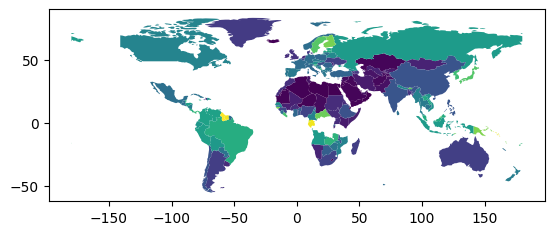

In [30]:
a.plot(column='forest_share')

In [29]:
a.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry',
       'entity', 'code', 'year', 'forest_share', 'forest_share__annotations'],
      dtype='object', length=174)

In [ ]:
df[['entity', 

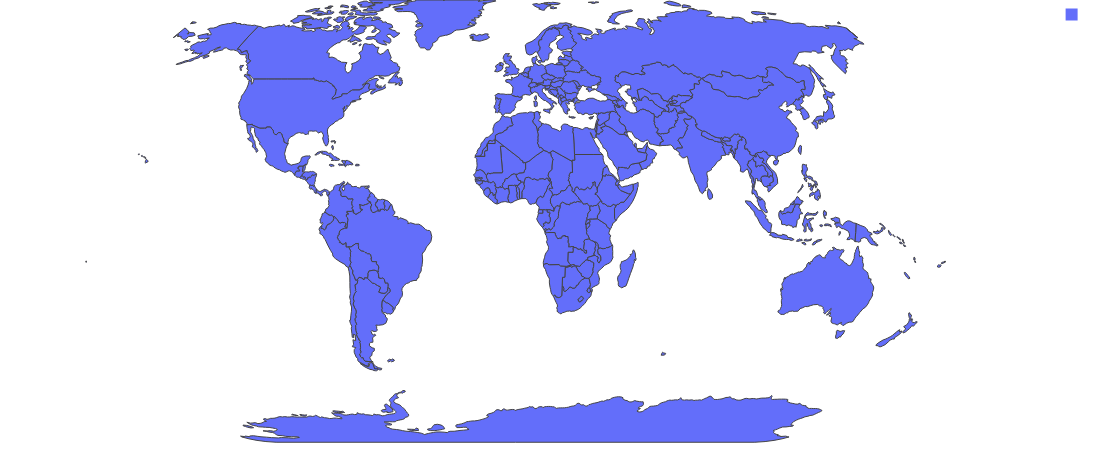

In [15]:
fig = px.choropleth(gdf, geojson=gdf.geometry, locations=df.index, color_continuous_scale="Viridis", projection="natural earth")
fig.update_geos(
    fitbounds="locations", 
    visible=False,
    center={"lat": 20, "lon": 0}
)
fig.update_layout(
    height=450,
    margin={"r":0,"t":0,"l":0,"b":0},
)

In [16]:
gdf.merge(df,left_on=')

MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

In [ ]:

df = df[df['year'] == year]

fig.update_traces(
    selector=dict(type='choropleth'),
    locations=filtered_df.index,
    z=filtered_df[column_name],
    colorscale='Plasma'
)
fig.update_geos(fitbounds="locations", visible=False)

# Remove margin from the figure itself
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))

st.plotly_chart(fig, width='content', key=f"map_{column_name}")